#### Imports

In [58]:
import importlib
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import pickle
from sklearn.model_selection import train_test_split

import globals
import utils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", device)

Current device: cuda


In [59]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Master_Thesis\\utils.py'>

In [60]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [61]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))
X_tr, X_val, Y_tr, Y_val = train_test_split(X, Y_resh, test_size=0.2, random_state=42)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("wavelengths shape:", wavelengths.shape)
print()
print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("Y_tr shape:", Y_tr.shape)
print("Y_val shape:", Y_val.shape)

X shape: (500, 9)
Y shape: (500, 25230)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (100, 9)
Y_tr shape: (400, 6, 4205)
Y_val shape: (100, 6, 4205)


In [62]:
class Encoder(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(9, 64),
            nn.SiLU(),
            nn.Linear(64, 128),
            nn.SiLU(),
            nn.Linear(128, z_dim),
            nn.SiLU()
        )

    def forward(self, x):
        return self.net(x)
    
class SpectralDecoder(nn.Module):
    def __init__(self, z_dim=128, channels=64):
        super().__init__()

        self.fc = nn.Linear(z_dim, channels * 64)

        self.cnn = nn.Sequential(
            nn.Conv1d(channels, 64, 5, padding=2),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Conv1d(64, 32, 5, padding=2),
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            nn.Conv1d(32, 1, 5, padding=2),
        )

    def forward(self, z):
        x = self.fc(z).view(z.size(0), 64, 64)
        x = self.cnn[:-1](x)   # all conv + norm + activation except last layer
        x = F.interpolate(x, size=4205, mode="linear", align_corners=False)
        x = self.cnn[-1](x).squeeze(1)
        return x
    
class EmulatorSet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()

        self.decoders = nn.ModuleList([
            SpectralDecoder() for _ in range(6)
        ])

    def forward(self, x):
        z = self.encoder(x)
        return [dec(z) for dec in self.decoders]

In [63]:
# quick model test
model = EmulatorSet().to(device)
model.eval()

# dummy input: (batch_size, 9)
x = torch.tensor(X_tr[0], dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    y = model(x)

# y is a list of 6 tensors, each (B, 4205)
for i, yi in enumerate(y):
    print(i+1, yi.shape)

1 torch.Size([1, 4205])
2 torch.Size([1, 4205])
3 torch.Size([1, 4205])
4 torch.Size([1, 4205])
5 torch.Size([1, 4205])
6 torch.Size([1, 4205])


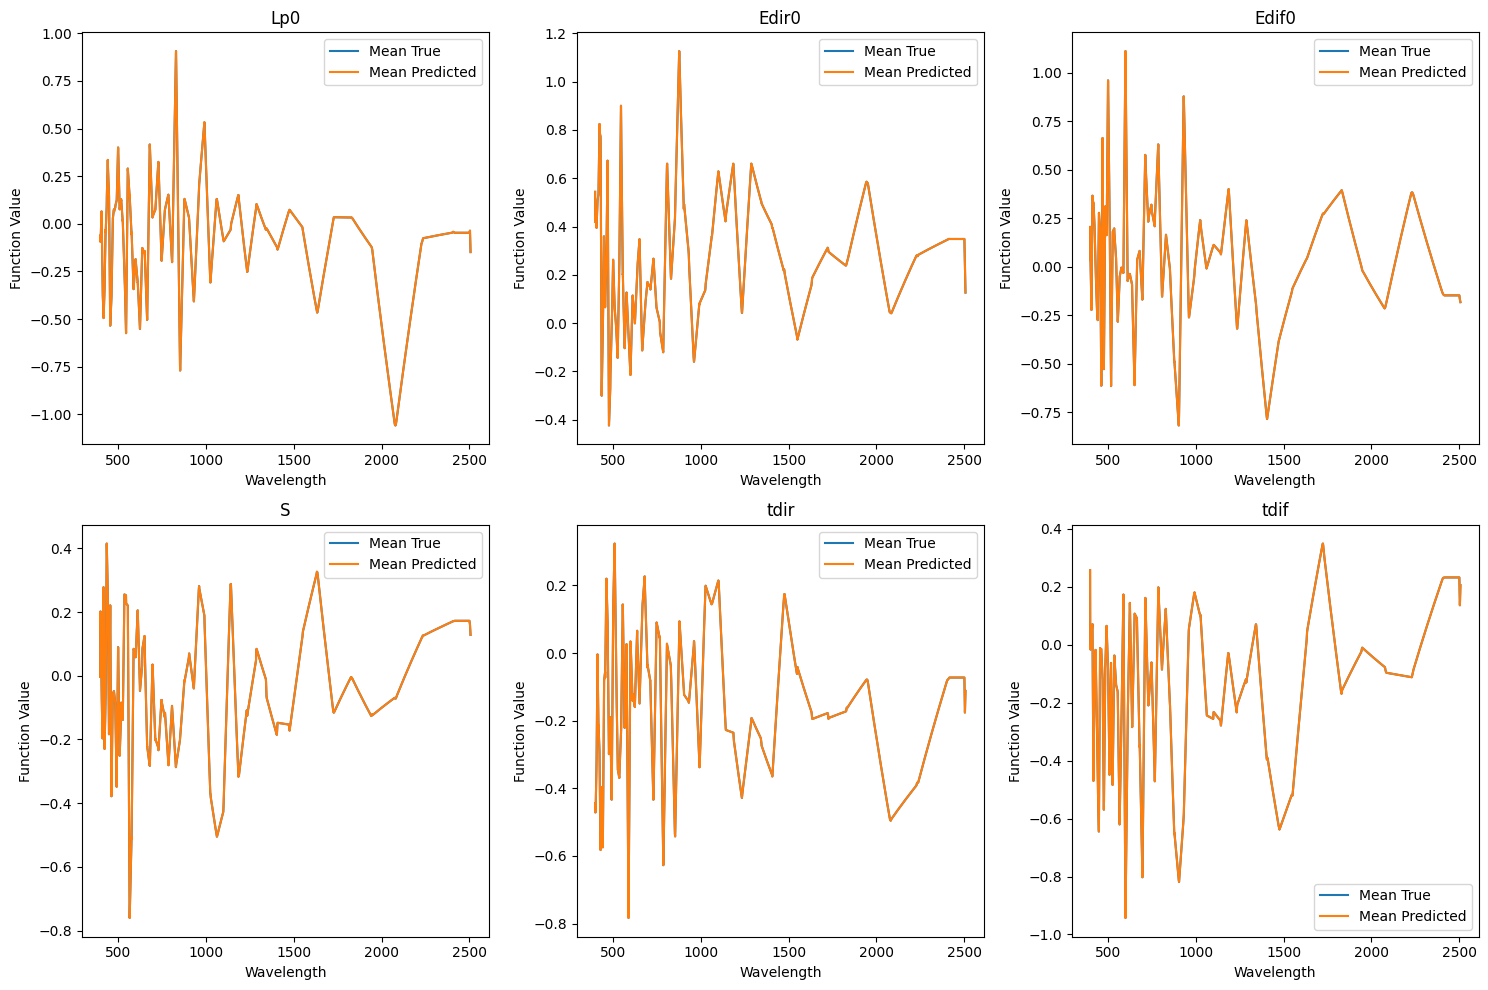

In [69]:
y_np = []
plt.figure(figsize=(15, 10))
for i in range(globals.N_FUNCTIONS):  # iterate over functions
    y_np.append(y[i].squeeze(0).cpu().numpy())

    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, y_np[i], label="Mean True")
    plt.plot(wavelengths, y_np[i], label="Mean Predicted")

    plt.title(f"{function_names[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()

plt.tight_layout()
plt.show()